## Sagnac Frequency - Backscatter Correction - Compare Setups

Explore the longterm behaviour of the RV sagnac beat

## Imports

In [2]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np

from datetime import datetime, date
from pandas import DataFrame, read_pickle, date_range, concat, read_csv
from obspy import UTCDateTime, read, Trace, Stream, read_inventory
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter1d


import sys
sys.path.append("../")

from functions.get_fft import __get_fft
from functions.multitaper_psd import __multitaper_psd
from functions.welch_psd import __welch_psd
from functions.rotate_romy_ZUV_ZNE import __rotate_romy_ZUV_ZNE
from functions.reduce import __reduce
from functions.load_backscatter_data import __load_backscatter_data
from functions.backscatter_correction import __backscatter_correction

from functions.read_sds import __read_sds

In [3]:
if os.uname().nodename == 'lighthouse':
    root_path = '/home/andbro/'
    data_path = '/home/andbro/kilauea-data/'
    archive_path = '/home/andbro/freenas/'
    bay_path = '/home/andbro/ontap-ffb-bay200/'
    lamont_path = '/home/andbro/lamont/'
elif os.uname().nodename == 'kilauea':
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'
elif os.uname().nodename in ['lin-ffb-01', 'ambrym', 'hochfelln']:
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'

## Configurations

In [4]:
config = {}

config['ring'] = "Z"

# config['delta'] = 120

# small event
# config['tbeg'] = UTCDateTime("2024-10-23 15:00")
# config['tend'] = UTCDateTime("2024-10-23 16:00")

# morocco event
config['tbeg'] = UTCDateTime("2023-09-08 22:00")
config['tend'] = UTCDateTime("2023-09-09 00:00")-0.1

# config['tbeg'] = UTCDateTime("2024-11-04 00:00")
# config['tend'] = UTCDateTime("2024-11-04 04:00")

# path to Sagnac data
config['path_to_data1'] = archive_path+"romy_archive/"
config['path_to_data2'] = data_path+"sagnac_frequency/data/demod/"

# config['path_to_out_data'] = data_path+"sagnac_frequency/data/"

# path to out figures
config['path_to_figs'] = data_path+"sagnac_frequency/figures/"


In [4]:
inv = read_inventory(data_path+"stationxml_ringlaser/"+"station_BW_ROMY.xml")

In [5]:
st1 = __read_sds(config['path_to_data1'], "BW.ROMY.10.BJZ", config['tbeg'], config['tend'])

st1 = st1.remove_sensitivity(inv)

st1 = st1.detrend("demean")

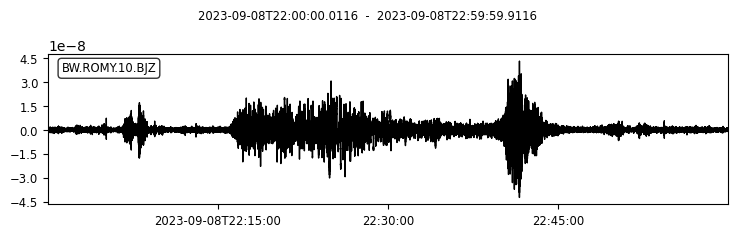

In [6]:
st1.plot();

In [7]:
# fband = 10Hz
# st1 = __read_sds(config['path_to_data2'], "BW.ROMY..BJZ", config['tbeg'], config['tend'])
# fband = 1Hz
# st2 = __read_sds(config['path_to_data2'], "BW.ROMY.10.BJZ", config['tbeg'], config['tend'])

# reference 20 [ f=10Hz, CA(off), AS(off), ]
# st2 = __read_sds(config['path_to_data2'], "BW.ROMY.20.BJZ", config['tbeg'], config['tend'])

# reference 21 [ f=10Hz, CA(on), SS(off), ]
# st2 = __read_sds(config['path_to_data2'], "BW.ROMY.21.BJZ", config['tbeg'], config['tend'])

# reference 22 [ f=10Hz, CA(off), SS(on), ]
# st2 = __read_sds(config['path_to_data2'], "BW.ROMY.22.BJZ", config['tbeg'], config['tend'])

# reference 23 [ f=10Hz, CA(on), SS(on), ]
st2 = __read_sds(config['path_to_data2'], "BW.ROMY.23.BJZ", config['tbeg'], config['tend'])


In [8]:
# scaling correction
for tr in st2:
    tr.data *= 0.75
    # tr.data *= 1/np.sqrt(np.pi)

In [9]:
f1, s1, p1 = __get_fft(st1[0].data, st1[0].stats.delta, window="hann")
f2, s2, p2 = __get_fft(st2[0].data, st2[0].stats.delta, window="hann")

# plt.figure()
# plt.loglog(f1, s1)
# plt.loglog(f2, s2)

# plt.figure()
# plt.plot(f1, np.unwrap(p1))
# plt.plot(f2, np.unwrap(p2))

# plt.xscale("log")
# # plt.yscale("log")

## Compare frequency band set

In [5]:
from functions.spectra_class import spectra

In [6]:
st5 = Stream()

# fband = 10Hz
st5 += __read_sds(config['path_to_data2'], "BW.ROMY..BJZ", config['tbeg'], config['tend'])

# fband = 1Hz
st5 += __read_sds(config['path_to_data2'], "BW.ROMY.10.BJZ", config['tbeg'], config['tend'])


In [7]:
st5

1 Trace(s) in Stream:
BW.ROMY..BJZ | 2023-09-08T22:00:00.000000Z - 2023-09-08T23:59:59.900000Z | 20.0 Hz, 143999 samples

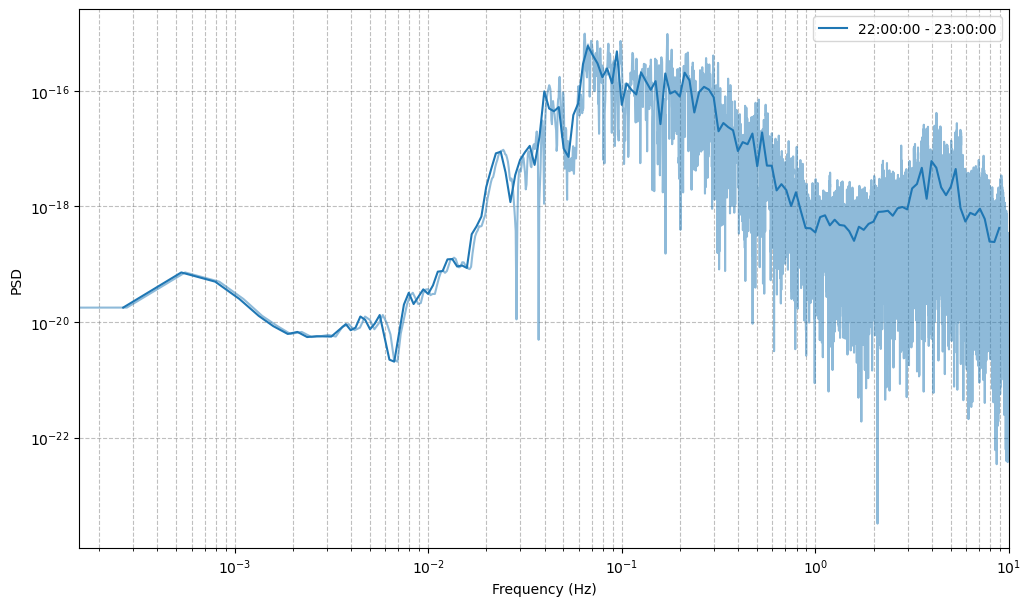

In [9]:
specs = spectra(st5[0], mode="psd")

specs.get_collection(tinterval=3600, toverlap=0, twin_sec=3600)

specs.get_fband_average(fraction_of_octave=12, average="mean")

specs.plot(mode="all")


## Filter

In [10]:
fmin, fmax = 0.001, 0.2

st10 = st1.copy()
st20 = st2.copy()
st10.detrend("demean")
st10.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
st20.detrend("demean")
st20.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

1 Trace(s) in Stream:
BW.ROMY.23.BJZ | 2023-09-08T22:00:00.000000Z - 2023-09-08T22:59:59.900000Z | 20.0 Hz, 71999 samples

In [11]:
%matplotlib tk

In [12]:
def __makeplot_spectra(st01, st02, db=True):

    from numpy import log10

    arr1 = st01[0].data
    arr2 = st02[0].data

    f1, s1, p1 = __get_fft(arr1, st1[0].stats.delta, window="hann")
    f2, s2, p2 = __get_fft(arr2, st2[0].stats.delta, window="hann")

    if db:
        s1 = 20*log10(s1)
        s2 = 20*log10(s2)

    font = 12

    fig, ax = plt.subplots(1, 1, figsize=(12, 5))

    cols = ["tab:blue", "tab:red", "tab:orange", "tab:green", "darkblue"]

    ax.plot(f1, s1, color="tab:orange", label="1", alpha=0.8)

    ax.plot(f2, s2, color="tab:green", label="2", alpha=0.8, ls="-")

    ax2 = ax.twinx()

    ax2.fill_between(f2, 0, abs(s2-s1),
                     color="gray", alpha=0.4
                    )

    ax2.set_ylim(0, 60)
    ax2.set_ylabel(r"|PSD$_{1}$ - PSD$_{2}$| (dB wrt. 1 rad/s/$\sqrt{Hz}$)", fontsize=font)

    ax.set_xlabel("Frequenc (Hz)", fontsize=font)
    ax.set_ylabel(r"PSD (dB wrt. 1 rad/s/$\sqrt{Hz}$)", fontsize=font)

    # ax.vyscale("log")
    ax.set_xscale("log")

    ax.set_title(f"{str(config['tbeg'])[:19].replace('T',' ')} - {str(config['tend'])[:19].replace('T',' ')}")

    ax.grid(ls="--", color="gray", alpha=0.4, which="both")

    ax.set_ylim(-300, -150)
    ax.set_xlim(1e-3, 5e0)

    ax.legend(ncol=2)

    import numpy as np
    axy = np.linspace(ax.get_yticks()[0], ax.get_yticks()[-1], len(ax.get_yticks()))
    ax2y = np.linspace(ax2.get_yticks()[0], ax2.get_yticks()[-1], len(ax.get_yticks()))
    ax2.set_yticks(ax2y)

    plt.show();
    return fig

In [13]:
fig = __makeplot_spectra(st1, st2)

In [14]:
def __makeplot_waveforms(st01, st02, db=True):

    yscale, yunit = 1e9, "nrad/s"
    tscale, tunit = 1/60, "min"

    arr1 = st01[0].data*yscale
    arr2 = st02[0].data*yscale

    t1 = st01[0].times(reftime=config['tbeg'])*tscale
    t2 = st02[0].times(reftime=config['tbeg'])*tscale

    font = 12

    fig, ax = plt.subplots(1, 1, figsize=(12, 5))

    cols = ["tab:blue", "tab:red", "tab:orange", "tab:green", "darkblue"]

    ax.plot(t1, arr1, color="tab:orange", label="1", alpha=0.8)

    ax.plot(t2, arr2, color="tab:green", label="2", alpha=0.8, ls="-")

    ax2 = ax.twinx()
    ax2.tick_params(axis='y', colors="gray")

    ax2.fill_between(t1, 0, abs(arr1-arr2),
                     color="gray", alpha=0.4
                    )

    ax2.set_ylim(bottom=0, top=1)
    ax2.set_ylabel(f"|$\Omega_1$ - $\Omega_2$| ({yunit})", fontsize=font, color="gray")

    ax.set_xlabel(f"Time ({tunit})", fontsize=font)
    ax.set_ylabel(f"$\Omega$ ({yunit})", fontsize=font)

    # ax.vyscale("log")
    # ax.set_xscale("log")

    ax.set_title(f"{str(config['tbeg'])[:19].replace('T',' ')} - {str(config['tend'])[:19].replace('T',' ')}")

    # ax.grid(ls="--", color="gray", alpha=0.4, which="both")

    # ax.set_ylim(-300, -200)
    # ax.set_xlim(1e-3, 5e0)

    ax.legend(ncol=2)

    plt.show();
    return fig

In [15]:
fig = __makeplot_waveforms(st10, st20)

In [16]:
df0 = 5000

df = 1/60
dt = 1/df

t = np.arange(0, 5000*3600, 1)
x = np.random.rand(5000*3600)

NN = x.size

dN = int(df0 * dt)

# indices
N1 = np.arange(0, NN, dN).astype(int)
N2 = np.arange(0, NN, dN).astype(int)+dN-1
# N2[-1] = NN-1

avg = np.zeros(len(N1))
ttt = np.zeros(len(N1))

for k, (n1, n2) in enumerate(zip(N1, N2)):
    avg[k] = (np.median(x[n1:n2]))
    ttt[k] = t[n1] + (t[n2] - t[n1])//2


In [17]:
plt.plot(t, x)
plt.plot(ttt, avg)

In [18]:
config['tbeg'] = UTCDateTime("2024-11-04 00:00")
config['tend'] = UTCDateTime("2024-11-05 00:00")

st2 = __read_sds(config['path_to_data2'], "BW.ROMY.XX.LJZ", config['tbeg'], config['tend'])


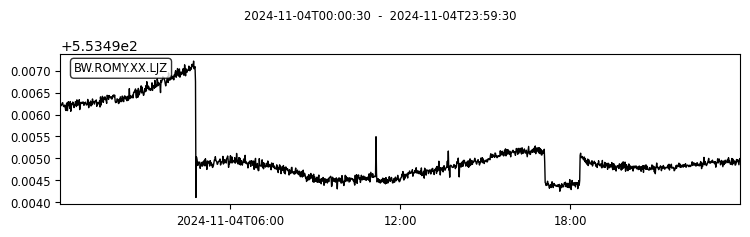

In [19]:
st2.plot()